<a href="https://colab.research.google.com/github/Ayan282/colab/blob/main/imtahananaliz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import random
import numpy as np
from datetime import date, timedelta

# =========================
# 1️⃣ CLEAN BASE SALES DATA
# =========================

days = []
start = date(2025, 1, 1)
for i in range(365):
    days.append((start + timedelta(days=i)).strftime('%Y-%m-%d'))

products = ['Lego Set','Toy Car','Doll','Puzzle','Board Game','Action Figure']
categories = ['Construction','Vehicle','Figure','Education','Game']
payment_types = ['Cash','Card','Online']
regions = ['North','South','East','West']
weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']

data = []

for i in range(1, 10001):
    price = random.randint(10, 100)
    quantity = random.randint(1, 10)
    discount = random.choice([0,5,10])

    data.append([
        i,                                      # sale_id
        random.choice(days),                    # date
        random.choice(products),                # product
        random.choice(categories),              # category
        price,                                  # price
        quantity,                               # quantity
        random.choice(regions),                 # region
        random.randint(7, 60),                  # customer_age
        random.choice(['M','F']),               # customer_gender
        discount,                               # discount
        price * quantity - discount,            # total_amount
        random.choice(payment_types),           # payment_type
        random.randint(1, 5),                   # product_rating
        random.choice([0,1]),                   # promotion_flag
        random.randint(0,100),                  # stock_left
        random.choice([0,1]),                   # return_flag
        random.choice(weekdays),                # weekday
        random.choice([0,1]),                   # holiday_flag
        random.randint(1, 20),                  # store_id
        f"Rep_{random.randint(1,50)}"           # sales_rep
    ])

columns = [
    'sale_id','date','product','category','price','quantity','region',
    'customer_age','customer_gender','discount','total_amount',
    'payment_type','product_rating','promotion_flag','stock_left',
    'return_flag','weekday','holiday_flag','store_id','sales_rep'
]

df = pd.DataFrame(data, columns=columns)

# =========================
# 2️⃣ DATA DIRTYING (CLEANING TEST)
# =========================

# ❌ Missing values (5%)
for col in ['price','quantity','customer_age','payment_type','product_rating']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

# ❌ Duplicate rows
duplicates = df.sample(800)
df = pd.concat([df, duplicates], ignore_index=True)

# ❌ Outliers
df.loc[df.sample(40).index, 'price'] = 9999
df.loc[df.sample(40).index, 'quantity'] = 300
df.loc[df.sample(30).index, 'customer_age'] = 150
df.loc[df.sample(30).index, 'total_amount'] = -500

# ❌ Logical errors
df.loc[df.sample(20).index, 'price'] = -25
df.loc[df.sample(20).index, 'discount'] = 500

# ❌ Category noise
df.loc[df.sample(100).index, 'payment_type'] = 'card'
df.loc[df.sample(100).index, 'payment_type'] = 'CARD '
df.loc[df.sample(100).index, 'payment_type'] = 'online '

# ❌ Date format issues
df.loc[df.sample(50).index, 'date'] = '10-01-2025'
df.loc[df.sample(50).index, 'date'] = 'Jan 10 2025'

In [12]:
df

,sale_id,date,product,category,price,quantity,region,customer_age,customer_gender,discount,total_amount,payment_type,product_rating,promotion_flag,stock_left,return_flag,weekday,holiday_flag,store_id,sales_rep
0,1,2025-02-19,Lego Set,Education,46.0,8.0,East,31.0,F,5,363,Cash,4.0,1,8,0,Tuesday,1,10,Rep_7
1,2,2025-02-25,Action Figure,Construction,34.0,1.0,East,NaN,F,5,29,Card,5.0,0,50,1,Monday,0,9,Rep_46
2,3,2025-12-21,Board Game,Game,27.0,2.0,East,48.0,M,0,54,Card,2.0,1,20,0,Monday,0,19,Rep_46
3,4,2025-03-20,Lego Set,Vehicle,28.0,4.0,West,7.0,M,0,112,Card,3.0,0,91,0,Tuesday,0,15,Rep_34
4,5,2025-03-31,Doll,Figure,38.0,2.0,West,60.0,M,5,71,Card,1.0,0,31,1,Monday,1,11,Rep_47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,8043,2025-08-20,Puzzle,Vehicle,86.0,8.0,South,49.0,F,5,683,Card,1.0,1,41,0,Tuesday,1,11,Rep_22
10796,6064,2025-12-13,Toy Car,Construction,23.0,6.0,North,21.0,F,5,133,Cash,4.0,1,9,1,Tuesday,0,11,Rep_14
10797,440,2025-09-22,Lego Set,Figure,54.0,5.0,South,51.0,F,5,265,Online,5.0,1,74,1,Monday,0,2,Rep_30
10798,9056,2025-12-01,Lego Set,Figure,71.0,4.0,South,35.0,F,0,284,Card,1.0,0,23,1,Thursday,0,6,Rep_48


In [13]:
df.shape

(10800, 20)

In [134]:
df.drop_duplicates(inplace=True)

In [14]:
df.head()

,sale_id,date,product,category,price,quantity,region,customer_age,customer_gender,discount,total_amount,payment_type,product_rating,promotion_flag,stock_left,return_flag,weekday,holiday_flag,store_id,sales_rep
0,1,2025-02-19,Lego Set,Education,46.0,8.0,East,31.0,F,5,363,Cash,4.0,1,8,0,Tuesday,1,10,Rep_7
1,2,2025-02-25,Action Figure,Construction,34.0,1.0,East,NaN,F,5,29,Card,5.0,0,50,1,Monday,0,9,Rep_46
2,3,2025-12-21,Board Game,Game,27.0,2.0,East,48.0,M,0,54,Card,2.0,1,20,0,Monday,0,19,Rep_46
3,4,2025-03-20,Lego Set,Vehicle,28.0,4.0,West,7.0,M,0,112,Card,3.0,0,91,0,Tuesday,0,15,Rep_34
4,5,2025-03-31,Doll,Figure,38.0,2.0,West,60.0,M,5,71,Card,1.0,0,31,1,Monday,1,11,Rep_47


In [128]:
df.dropna(subset='a')

,sale_id,date,product,category,price,quantity,region,customer_age,customer_gender,discount,...,product_rating,promotion_flag,stock_left,return_flag,weekday,holiday_flag,store_id,sales_rep,avgprise,a


In [16]:
df.columns

Index(['sale_id', 'date', 'product', 'category', 'price', 'quantity', 'region',
       'customer_age', 'customer_gender', 'discount', 'total_amount',
       'payment_type', 'product_rating', 'promotion_flag', 'stock_left',
       'return_flag', 'weekday', 'holiday_flag', 'store_id', 'sales_rep'],
      dtype='object')

In [99]:
df.dropna(subset=["sale_id"])

,sale_id,date,product,category,price,quantity,region,customer_age,customer_gender,discount,...,payment_type,product_rating,promotion_flag,stock_left,return_flag,weekday,holiday_flag,store_id,sales_rep,avgprise
0,1,2025-02-19,Lego Set,Education,46.0,8.0,East,31.0,F,5,...,Cash,4.0,1,8,0,Tuesday,1,10,Rep_7,93.641076
1,2,2025-02-25,Action Figure,Construction,34.0,1.0,East,NaN,F,5,...,Card,5.0,1,50,1,Monday,0,9,Rep_46,93.641076
2,3,2025-12-21,Board Game,Game,27.0,2.0,East,48.0,M,0,...,Card,2.0,1,20,0,Monday,0,19,Rep_46,93.641076
3,4,2025-03-20,Lego Set,Vehicle,28.0,4.0,West,7.0,M,0,...,Card,3.0,1,91,0,Tuesday,0,15,Rep_34,93.641076
4,5,2025-03-31,Doll,Figure,38.0,2.0,West,60.0,M,5,...,Card,1.0,1,31,1,Monday,1,11,Rep_47,93.641076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,8043,2025-08-20,Puzzle,Vehicle,86.0,8.0,South,49.0,F,5,...,Card,1.0,1,41,0,Tuesday,1,11,Rep_22,93.641076
10796,6064,2025-12-13,Toy Car,Construction,23.0,6.0,North,21.0,F,5,...,Cash,4.0,1,9,1,Tuesday,0,11,Rep_14,93.641076
10797,440,2025-09-22,Lego Set,Figure,54.0,5.0,South,51.0,F,5,...,Online,5.0,1,74,1,Monday,0,2,Rep_30,93.641076
10798,9056,2025-12-01,Lego Set,Figure,71.0,4.0,South,35.0,F,0,...,Card,1.0,1,23,1,Thursday,0,6,Rep_48,93.641076


In [17]:
df.isnull().sum()

,0
sale_id,0
date,0
product,0
category,0
price,536
quantity,542
region,0
customer_age,536
customer_gender,0
discount,0


In [18]:
df.describe()

,sale_id,price,quantity,customer_age,discount,total_amount,product_rating,promotion_flag,stock_left,return_flag,holiday_flag,store_id
count,10800.000000,10264.000000,10258.000000,10264.000000,10800.000000,10800.000000,10270.000000,10800.000000,10800.000000,10800.000000,10800.000000,10800.000000
mean,5003.193426,93.641076,6.662020,33.828917,5.925463,297.377870,2.996203,0.503148,50.086944,0.500093,0.502037,10.501667
std,2882.892411,620.162856,18.575919,16.735325,21.667616,231.043371,1.421934,0.500013,29.224732,0.500023,0.500019,5.708494
min,1.000000,-25.000000,1.000000,7.000000,0.000000,-500.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2506.750000,32.000000,3.000000,20.000000,0.000000,111.000000,2.000000,0.000000,25.000000,0.000000,0.000000,6.000000
50%,4999.500000,55.000000,6.000000,34.000000,5.000000,242.000000,3.000000,1.000000,50.000000,1.000000,1.000000,10.000000
75%,7497.250000,78.000000,8.000000,47.000000,10.000000,441.500000,4.000000,1.000000,75.000000,1.000000,1.000000,15.000000
max,10000.000000,9999.000000,300.000000,150.000000,500.000000,1000.000000,5.000000,1.000000,100.000000,1.000000,1.000000,20.000000


In [19]:
df.dtypes

,0
sale_id,int64
date,object
product,object
category,object
price,float64
quantity,float64
region,object
customer_age,float64
customer_gender,object
discount,int64


In [21]:
df['customer_gender'].value_counts()

,count
customer_gender,
F,5420
M,5380


In [20]:
df.groupby("customer_gender")['total_amount'].sum()

,total_amount
customer_gender,
F,1610963
M,1600718


<Axes: xlabel='product', ylabel='customer_age'>

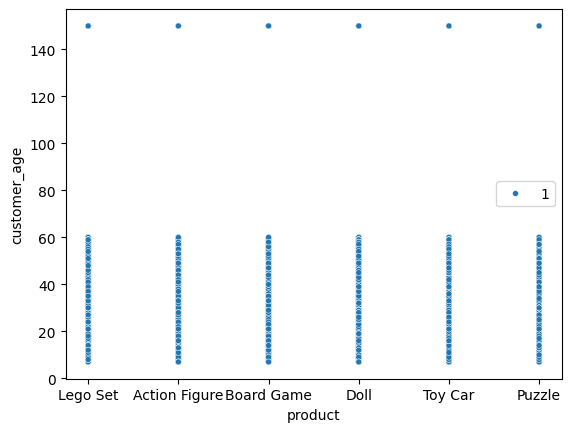

In [104]:
sns.scatterplot(data=df,x='product',y='customer_age',size=1)

In [30]:
df.groupby("customer_gender")['total_amount'].mean()

,total_amount
customer_gender,
F,297.225646
M,297.531227


In [28]:
df.groupby('region')['product']

In [29]:
df["total_amount"].describe()

,total_amount
count,10800.000000
mean,297.377870
std,231.043371
min,-500.000000
25%,111.000000
50%,242.000000
75%,441.500000
max,1000.000000


In [31]:
df['customer_age'].describe()

,customer_age
count,10264.000000
mean,33.828917
std,16.735325
min,7.000000
25%,20.000000
50%,34.000000
75%,47.000000
max,150.000000


In [32]:
df['promotion_flag'].value_counts()

,count
promotion_flag,
1,5434
0,5366


In [41]:
df.groupby('product')['customer_age'].mean()

,customer_age
product,
Action Figure,33.885813
Board Game,33.979677
Doll,34.598039
Lego Set,33.114853
Puzzle,34.025057
Toy Car,33.335094


her mehsula en cox teleb orta yasli insanlar terefinden olur


In [42]:
df.groupby('product')['customer_age'].min()

,customer_age
product,
Action Figure,7.0
Board Game,7.0
Doll,7.0
Lego Set,7.0
Puzzle,7.0
Toy Car,7.0


In [43]:
df.groupby('product')['customer_age'].max()

,customer_age
product,
Action Figure,150.0
Board Game,150.0
Doll,150.0
Lego Set,150.0
Puzzle,150.0
Toy Car,150.0


In [46]:
df.groupby('region')['customer_age'].mean()

,customer_age
region,
East,33.984332
North,34.351501
South,33.693687
West,33.303483


In [71]:
df.groupby('region')['total_amount'].max()

,total_amount
region,
East,990
North,1000
South,1000
West,1000


In [49]:
df['product'].value_counts()

,count
product,
Puzzle,1858
Doll,1837
Action Figure,1805
Toy Car,1781
Lego Set,1766
Board Game,1753


In [50]:
df['payment_type'].value_counts()

,count
payment_type,
Card,3444
Cash,3312
Online,3217
online,100
CARD,99
card,98


Card ile odeyenler en coxdur


In [117]:
df['weekday'].value_counts()

In [52]:
df.groupby('product')['stock_left'].mean()

,stock_left
product,
Action Figure,50.954571
Board Game,49.609241
Doll,50.015787
Lego Set,49.025481
Puzzle,50.113563
Toy Car,50.775969


In [85]:
df['product_rating'].max()

5.0

In [54]:
df['product_rating'].min()

1.0

In [55]:
df['promotion_flag'].value_counts()

,count
promotion_flag,
1,5434
0,5366


In [56]:
df['return_flag'].value_counts()

,count
return_flag,
1,5401
0,5399


In [69]:
df['stock_left'].value_counts()

,count
stock_left,
94,128
62,128
70,127
2,126
54,125
...,...
13,90
72,90
44,82


In [66]:
df.sort_values(by='date',ascending=False)

,sale_id,date,product,category,price,quantity,region,customer_age,customer_gender,discount,total_amount,payment_type,product_rating,promotion_flag,stock_left,return_flag,weekday,holiday_flag,store_id,sales_rep
2630,2631,Jan 10 2025,Doll,Game,78.0,9.0,North,31.0,M,5,697,Online,2.0,0,92,0,Monday,0,6,Rep_37
7834,7835,Jan 10 2025,Board Game,Vehicle,37.0,6.0,North,36.0,M,0,-500,Online,2.0,0,75,0,Thursday,0,16,Rep_43
6273,6274,Jan 10 2025,Puzzle,Game,NaN,2.0,East,36.0,M,10,30,Cash,2.0,0,9,0,Tuesday,0,17,Rep_7
1045,1046,Jan 10 2025,Board Game,Education,85.0,1.0,South,27.0,M,5,80,Cash,3.0,0,28,1,Friday,0,11,Rep_25
3589,3590,Jan 10 2025,Doll,Figure,72.0,6.0,East,55.0,F,5,427,Cash,2.0,1,100,1,Tuesday,1,1,Rep_23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6557,6558,10-01-2025,Toy Car,Construction,39.0,7.0,East,43.0,M,10,263,Cash,2.0,1,53,0,Thursday,0,14,Rep_35
6547,6548,10-01-2025,Action Figure,Game,22.0,5.0,West,57.0,F,0,110,Card,3.0,0,95,1,Thursday,1,7,Rep_47
6514,6515,10-01-2025,Toy Car,Figure,32.0,2.0,South,21.0,M,0,64,Online,5.0,1,80,0,Thursday,1,10,Rep_26
6329,6330,10-01-2025,Action Figure,Education,52.0,9.0,West,35.0,M,0,468,Card,1.0,0,27,1,Thursday,1,12,Rep_13


In [68]:
df.sort_values(by='price',ascending=False).head(10)

,sale_id,date,product,category,price,quantity,region,customer_age,customer_gender,discount,total_amount,payment_type,product_rating,promotion_flag,stock_left,return_flag,weekday,holiday_flag,store_id,sales_rep
4187,4188,2025-09-10,Action Figure,Construction,9999.0,10.0,West,36.0,M,5,305,Card,3.0,1,31,0,Tuesday,1,1,Rep_47
7388,7389,2025-05-10,Action Figure,Vehicle,9999.0,6.0,West,NaN,M,5,415,Online,3.0,1,19,1,Thursday,1,5,Rep_33
10636,2600,2025-02-17,Action Figure,Figure,9999.0,8.0,West,18.0,F,5,131,Online,1.0,1,58,0,Wednesday,0,19,Rep_27
3588,3589,2025-04-05,Board Game,Game,9999.0,3.0,East,26.0,M,10,107,Card,5.0,0,61,1,Monday,0,12,Rep_13
10325,1148,2025-12-04,Lego Set,Construction,9999.0,7.0,East,28.0,M,0,434,Card,1.0,1,4,0,Wednesday,0,1,Rep_12
7002,7003,2025-08-06,Action Figure,Figure,9999.0,3.0,North,26.0,F,0,282,Cash,4.0,0,12,0,Monday,1,15,Rep_25
6538,6539,2025-05-21,Lego Set,Construction,9999.0,2.0,South,53.0,F,10,152,Card,3.0,0,15,0,Monday,1,10,Rep_44
6817,6818,2025-05-08,Action Figure,Education,9999.0,2.0,North,24.0,M,0,62,Online,3.0,1,51,0,Tuesday,1,2,Rep_21
6336,6337,2025-06-07,Puzzle,Game,9999.0,4.0,East,48.0,M,0,356,Card,2.0,1,19,1,Thursday,0,5,Rep_7
7720,7721,2025-08-19,Action Figure,Education,9999.0,10.0,West,41.0,F,0,770,Cash,2.0,1,26,0,Wednesday,0,4,Rep_33


In [90]:
df['avgprise']=df['price'].mean()
df['price']>df['avgprise']

,0
0,False
1,False
2,False
3,False
4,False
...,...
10795,False
10796,False
10797,False
10798,False


In [91]:
df.corr(numeric_only=True)

,sale_id,price,quantity,customer_age,discount,total_amount,product_rating,promotion_flag,stock_left,return_flag,holiday_flag,store_id,avgprise
sale_id,1.000000,0.005662,-0.012025,-0.007327,-0.004549,0.013072,0.009216,NaN,-0.001870,0.007621,0.008669,-0.007261,NaN
price,0.005662,1.000000,0.019854,-0.002837,-0.004882,0.017452,0.004554,NaN,-0.007313,-0.013086,-0.003098,-0.016037,NaN
quantity,-0.012025,0.019854,1.000000,-0.010636,0.030709,0.120377,0.008175,NaN,0.011061,-0.002930,-0.007173,0.008397,NaN
customer_age,-0.007327,-0.002837,-0.010636,1.000000,-0.002850,-0.002515,0.005350,NaN,0.020770,0.003242,-0.001802,0.012810,NaN
discount,-0.004549,-0.004882,0.030709,-0.002850,1.000000,-0.012421,-0.012808,NaN,-0.006839,0.005654,0.005232,0.012159,NaN
total_amount,0.013072,0.017452,0.120377,-0.002515,-0.012421,1.000000,-0.008557,NaN,-0.009145,-0.001595,0.012278,0.009458,NaN
product_rating,0.009216,0.004554,0.008175,0.005350,-0.012808,-0.008557,1.000000,NaN,0.027449,0.010347,-0.002252,-0.011165,NaN
promotion_flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock_left,-0.001870,-0.007313,0.011061,0.020770,-0.006839,-0.009145,0.027449,NaN,1.000000,0.005357,-0.005148,-0.015834,NaN
return_flag,0.007621,-0.013086,-0.002930,0.003242,0.005654,-0.001595,0.010347,NaN,0.005357,1.000000,0.002777,-0.005661,NaN


In [97]:
import seaborn as sns
cols=['sale_id','price','quantity','customer_age','discount','total_amount','product_rating','promotion_flag','stock_left','return_flag','holiday_flag','store_id'].corr()
corr=data[cols].corr
sns.heatmap(df[cols].corr())

AttributeError: 'list' object has no attribute 'corr'

<BarContainer object of 10800 artists>

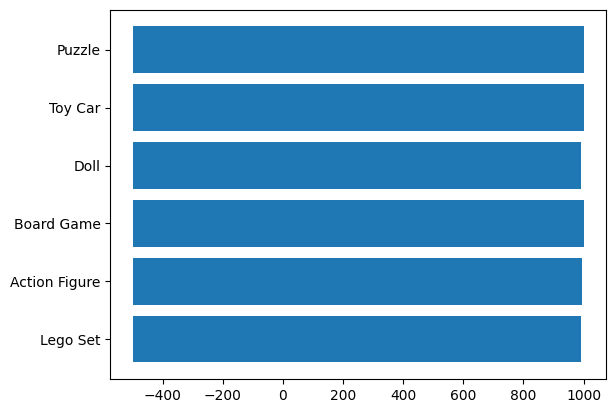

In [113]:
import matplotlib.pyplot as plt
plt.barh(df['product'],df['total_amount'])

<Axes: xlabel='weekday', ylabel='price'>

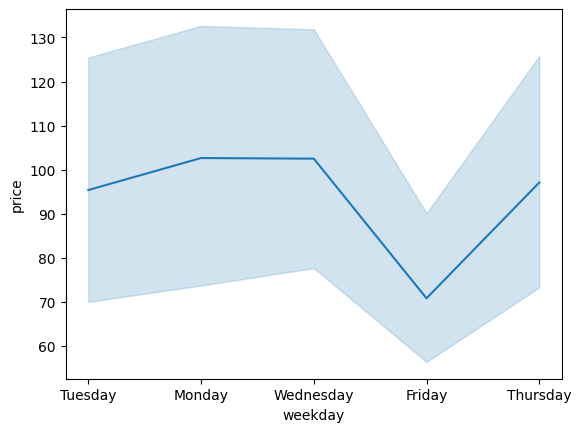

In [119]:
sns.lineplot(data=df,x='weekday',y='price')

<Axes: xlabel='weekday', ylabel='discount'>

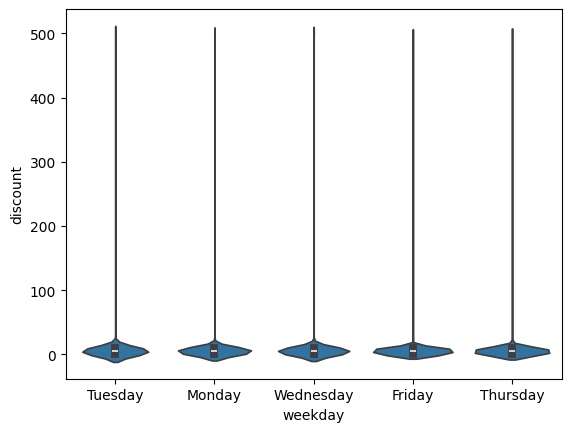

In [122]:
sns.violinplot(x='weekday',y='discount',data=df)

<Axes: xlabel='discount', ylabel='total_amount'>

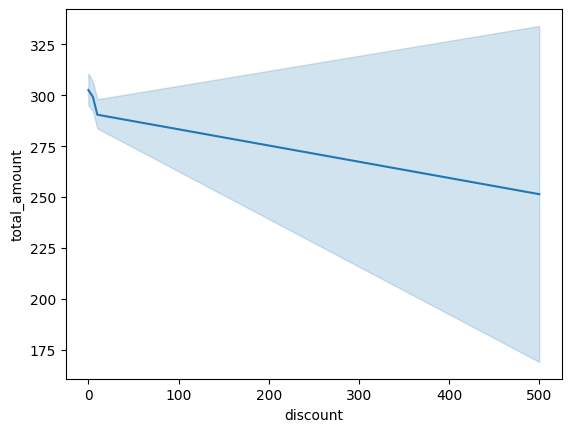

In [126]:
sns.lineplot(y='total_amount',x='discount',data=df)